In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams.update({
  'font.size': 16, 
  'grid.alpha': 0.25})

In [ ]:
def self_avoid(n, trials, rng=None):

  dead_ends = 0

  for t in range(trials):
    a = [[False for j in range(n)] for i in range(n)]
    x = n // 2
    y = n // 2

    while (x > 0) and (x < n-1) and (y > 0) and (y < n-1):
      # Check for dead end and make a random move
      a[x][y] = True
      if a[x-1][y] and a[x+1][y] and a[x][y-1] and a[x][y+1]:
        dead_ends += 1
        break

      r = rng.integers(1, 5)
      if (r == 1) and (not a[x+1][y]): x += 1
      elif (r == 2) and (not a[x-1][y]): x -= 1
      elif (r == 3) and (not a[x][y+1]): y += 1
      elif (r == 4) and (not a[x][y-1]): y -= 1
  
  print(f"({n:3d}, {trials:5d}): {100*dead_ends//trials:2d}% dead ends")

In [4]:
seed = 260306
rng = np.random.default_rng(seed)

n_and_trials_arr = [
  [5, 100], [20, 100], [40, 100], [80, 100],
  [5, 1000], [20, 1000], [40, 1000], [80, 1000]]

for n, trials in n_and_trials_arr:
  self_avoid(n, trials, rng=rng)

(  5,   100):  0% dead ends
( 20,   100): 29% dead ends
( 40,   100): 74% dead ends
( 80,   100): 99% dead ends
(  5,  1000):  0% dead ends
( 20,  1000): 32% dead ends
( 40,  1000): 76% dead ends
( 80,  1000): 98% dead ends


Self-avoiding random walks in a 21-by-21 brid

In [32]:
def self_avoid_illustrate(n):
  # seed = 260306
  seed = None
  rng = np.random.default_rng(seed)

  dead_ends = 0
  a = [[False for j in range(n)] for i in range(n)]

  x = n // 2
  y = n // 2
  paths = [[x, y]]

  while (x > 0) and (x < n-1) and (y > 0) and (y < n-1):
    # Check for dead end and make a random move
    a[x][y] = True
    if a[x-1][y] and a[x+1][y] and a[x][y-1] and a[x][y+1]:
      dead_ends += 1
      break

    r = rng.integers(1, 5)
    if (r == 1) and (not a[x+1][y]): x += 1
    elif (r == 2) and (not a[x-1][y]): x -= 1
    elif (r == 3) and (not a[x][y+1]): y += 1
    elif (r == 4) and (not a[x][y-1]): y -= 1

    paths.append([x, y])

  # print(dead_ends)

  x_data = [paths[i][0] for i in range(len(paths))]
  y_data = [paths[i][1] for i in range(len(paths))]

  fig, ax = plt.subplots()

  ax.plot(x_data[0], y_data[0], marker=".", color="k", markersize=15)
  ax.plot(y_data, x_data, linewidth=4, zorder=1)

  ax.set_xlim([0, n-1])
  ax.set_ylim([0, n-1])
  ax.set_aspect("equal")
  ax.invert_yaxis()
  ax.tick_params(top=False, labeltop=False, bottom=False, labelbottom=False)

  title = "dead end" if dead_ends else "escape"
  ax.set_title(f"{title}")

  ax.axis("off")

  # -- draw grids 
  for i in range(1, n-1):
    ax.plot([0.5, n-1-0.5], [i, i], color="k", linewidth=4, alpha=0.1, zorder=0)
    ax.plot([i, i], [0.5, n-1-0.5], color="k", linewidth=4, alpha=0.1, zorder=0)


  # for row in a:
  #   print([1 if a_ij else 0 for a_ij in row])

  plt.show(fig)
  
  return

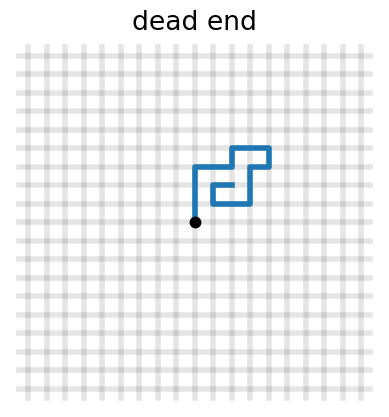

In [44]:
self_avoid_illustrate(21)

Draw `8 x 6 = 48` trials

In [46]:
# Calculate all paths
n = 21
# seed = 260306
seed = None
rng = np.random.default_rng(seed)

nrows = 8
ncols = 6

trials = nrows * ncols
paths_all_trials = []
for i in range(trials):

  dead_ends = [] 
  a = [[False for j in range(n)] for i in range(n)]

  x = n // 2
  y = n // 2
  paths = [[x, y]]

  while (x > 0) and (x < n-1) and (y > 0) and (y < n-1):
    # Check for dead end and make a random move
    a[x][y] = True
    if a[x-1][y] and a[x+1][y] and a[x][y-1] and a[x][y+1]:
      dead_ends += [1]
      break

    dead_ends += [0]

    r = rng.integers(1, 5)
    if (r == 1) and (not a[x+1][y]): x += 1
    elif (r == 2) and (not a[x-1][y]): x -= 1
    elif (r == 3) and (not a[x][y+1]): y += 1
    elif (r == 4) and (not a[x][y-1]): y -= 1

    paths.append([x, y])

  paths_all_trials += [paths]

paths_all_trials

[[[10, 10],
  [10, 9],
  [10, 8],
  [10, 7],
  [10, 7],
  [10, 7],
  [11, 7],
  [12, 7],
  [13, 7],
  [13, 7],
  [13, 8],
  [13, 8],
  [14, 8],
  [14, 9],
  [14, 9],
  [14, 9],
  [14, 10],
  [14, 11],
  [15, 11],
  [15, 10],
  [15, 10],
  [15, 9],
  [15, 9],
  [15, 8],
  [15, 8],
  [15, 7],
  [14, 7],
  [14, 7],
  [14, 7],
  [14, 7],
  [14, 7],
  [14, 7],
  [14, 7],
  [14, 7],
  [14, 7],
  [14, 7],
  [14, 6],
  [14, 5],
  [15, 5],
  [15, 4],
  [16, 4],
  [16, 4],
  [16, 3],
  [16, 3],
  [15, 3],
  [15, 2],
  [15, 2],
  [16, 2],
  [16, 2],
  [16, 2],
  [16, 2],
  [17, 2],
  [17, 1],
  [16, 1],
  [15, 1],
  [14, 1],
  [14, 2],
  [14, 3],
  [14, 3],
  [13, 3],
  [12, 3],
  [11, 3],
  [11, 2],
  [12, 2],
  [13, 2],
  [13, 2],
  [13, 2],
  [13, 1],
  [12, 1],
  [12, 1],
  [12, 1],
  [12, 0]],
 [[10, 10],
  [9, 10],
  [9, 9],
  [10, 9],
  [10, 9],
  [11, 9],
  [12, 9],
  [12, 9],
  [13, 9],
  [13, 8],
  [14, 8],
  [15, 8],
  [15, 8],
  [15, 9],
  [15, 9],
  [15, 10],
  [15, 10],
  [15, 11],


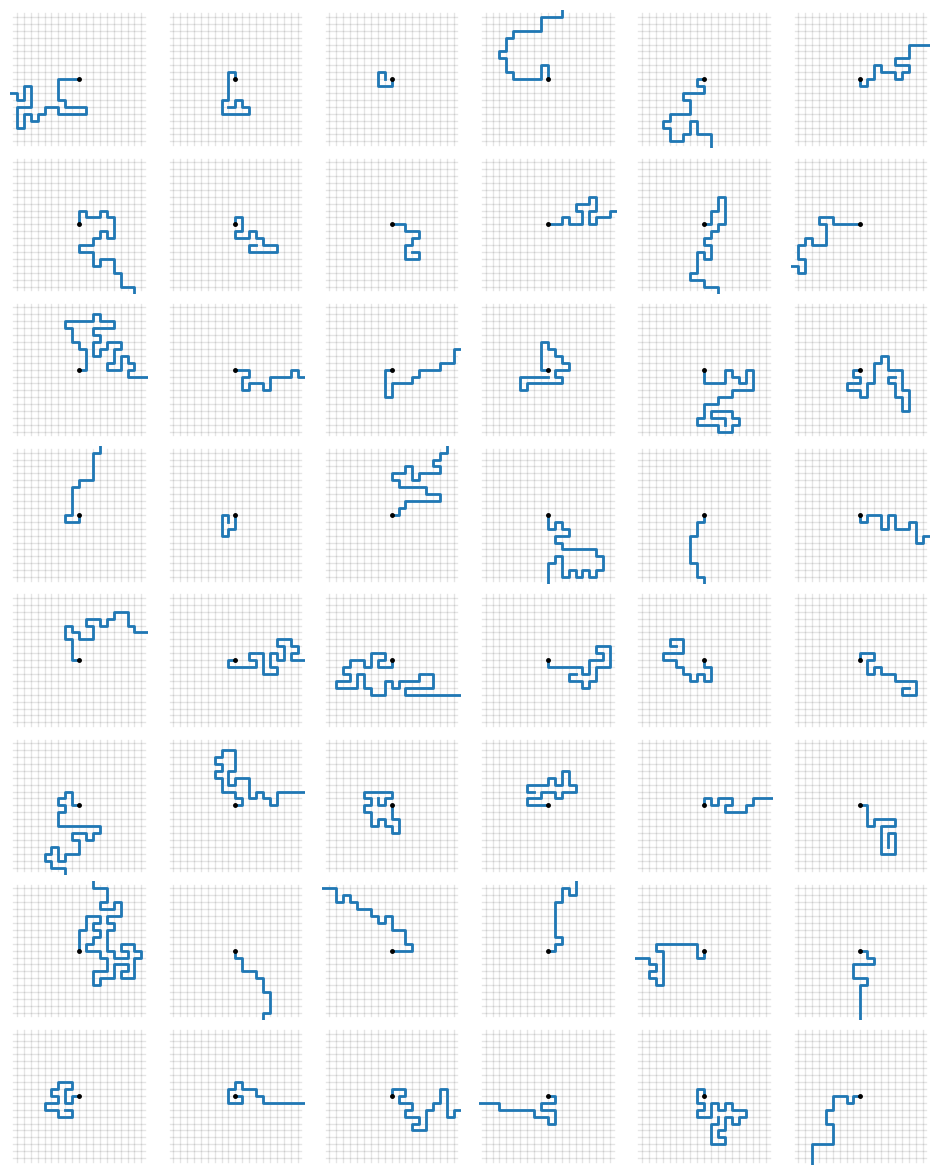

In [60]:
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(12, 15))

for i in range(trials):
  paths = paths_all_trials[i]

  x_data = [paths[i][0] for i in range(len(paths))]
  y_data = [paths[i][1] for i in range(len(paths))]

  ax_row_idx = i // ncols
  ax_col_idx = i % ncols
  axes[ax_row_idx, ax_col_idx].plot(x_data[0], y_data[0], marker=".", color="k", markersize=5)
  axes[ax_row_idx, ax_col_idx].plot(y_data, x_data, linewidth=2, zorder=1)

  axes[ax_row_idx, ax_col_idx].set_xlim([0, n-1])
  axes[ax_row_idx, ax_col_idx].set_ylim([0, n-1])
  axes[ax_row_idx, ax_col_idx].set_aspect("equal")
  axes[ax_row_idx, ax_col_idx].invert_yaxis()
  axes[ax_row_idx, ax_col_idx].tick_params(top=False, labeltop=False, bottom=False, labelbottom=False)
  axes[ax_row_idx, ax_col_idx].axis("off")

  # -- draw grids 
  for i in range(1, n-1):
    axes[ax_row_idx, ax_col_idx].plot([0.5, n-1-0.5], [i, i], color="k", linewidth=1, alpha=0.1, zorder=0)
    axes[ax_row_idx, ax_col_idx].plot([i, i], [0.5, n-1-0.5], color="k", linewidth=1, alpha=0.1, zorder=0)


  # for row in a:
  #   print([1 if a_ij else 0 for a_ij in row])

plt.subplots_adjust(wspace=0.05, hspace=0.05)
plt.show(fig)